**Author:** Dr. Alexis Hucteau  
**Contact:** [LinkedIn](https://www.linkedin.com/in/alexis-hucteau/) [Malt](https://www.malt.fr/profile/alexishucteau1)  
**Date:** May 2026

### Licensing Notice
- **Code:** This work is licensed under the [GNU GPL v3](https://www.gnu.org/licenses/gpl-3.0.html).
- **Analysis & Visualizations:** The interpretive content of this notebook is licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).

*Copyright (c) 2026 Alexis Hucteau. All rights reserved.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model = joblib.load('../models/drug_predictor_model.pkl')
pca_model = joblib.load('../models/pca_model.pkl')
gene_names_list = joblib.load('../models/gene_names_list.pkl')
cleaned_genes = [g.split(' ')[0] for g in gene_names_list]
X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet')
df_meta = pd.read_parquet('../data/processed/metadata_test.parquet')

In [135]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"--- Performance Globale ---")
print(f"R² Score : {r2:.3f}")
print(f"RMSE     : {rmse:.3f}")
print(f"MAE      : {mae:.3f}")

--- Performance Globale ---
R² Score : 0.794
RMSE     : 0.559
MAE      : 0.426


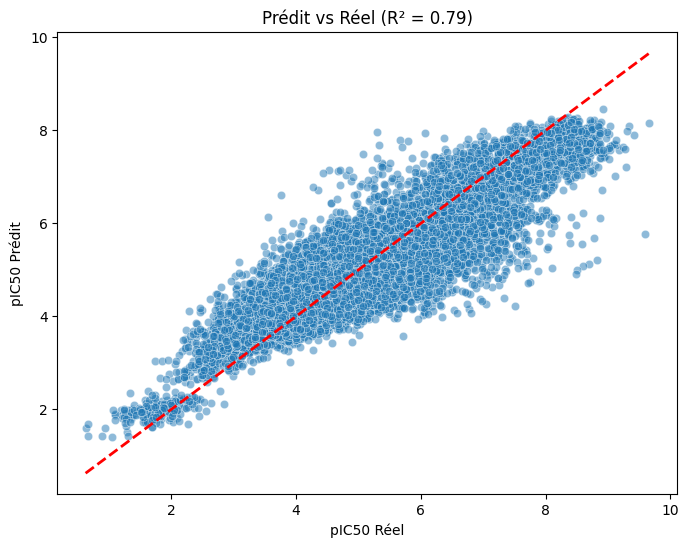

In [136]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test.values.flatten(), y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('pIC50 Réel')
plt.ylabel('pIC50 Prédit')
plt.title(f'Prédit vs Réel (R² = {r2:.2f})')
plt.show()

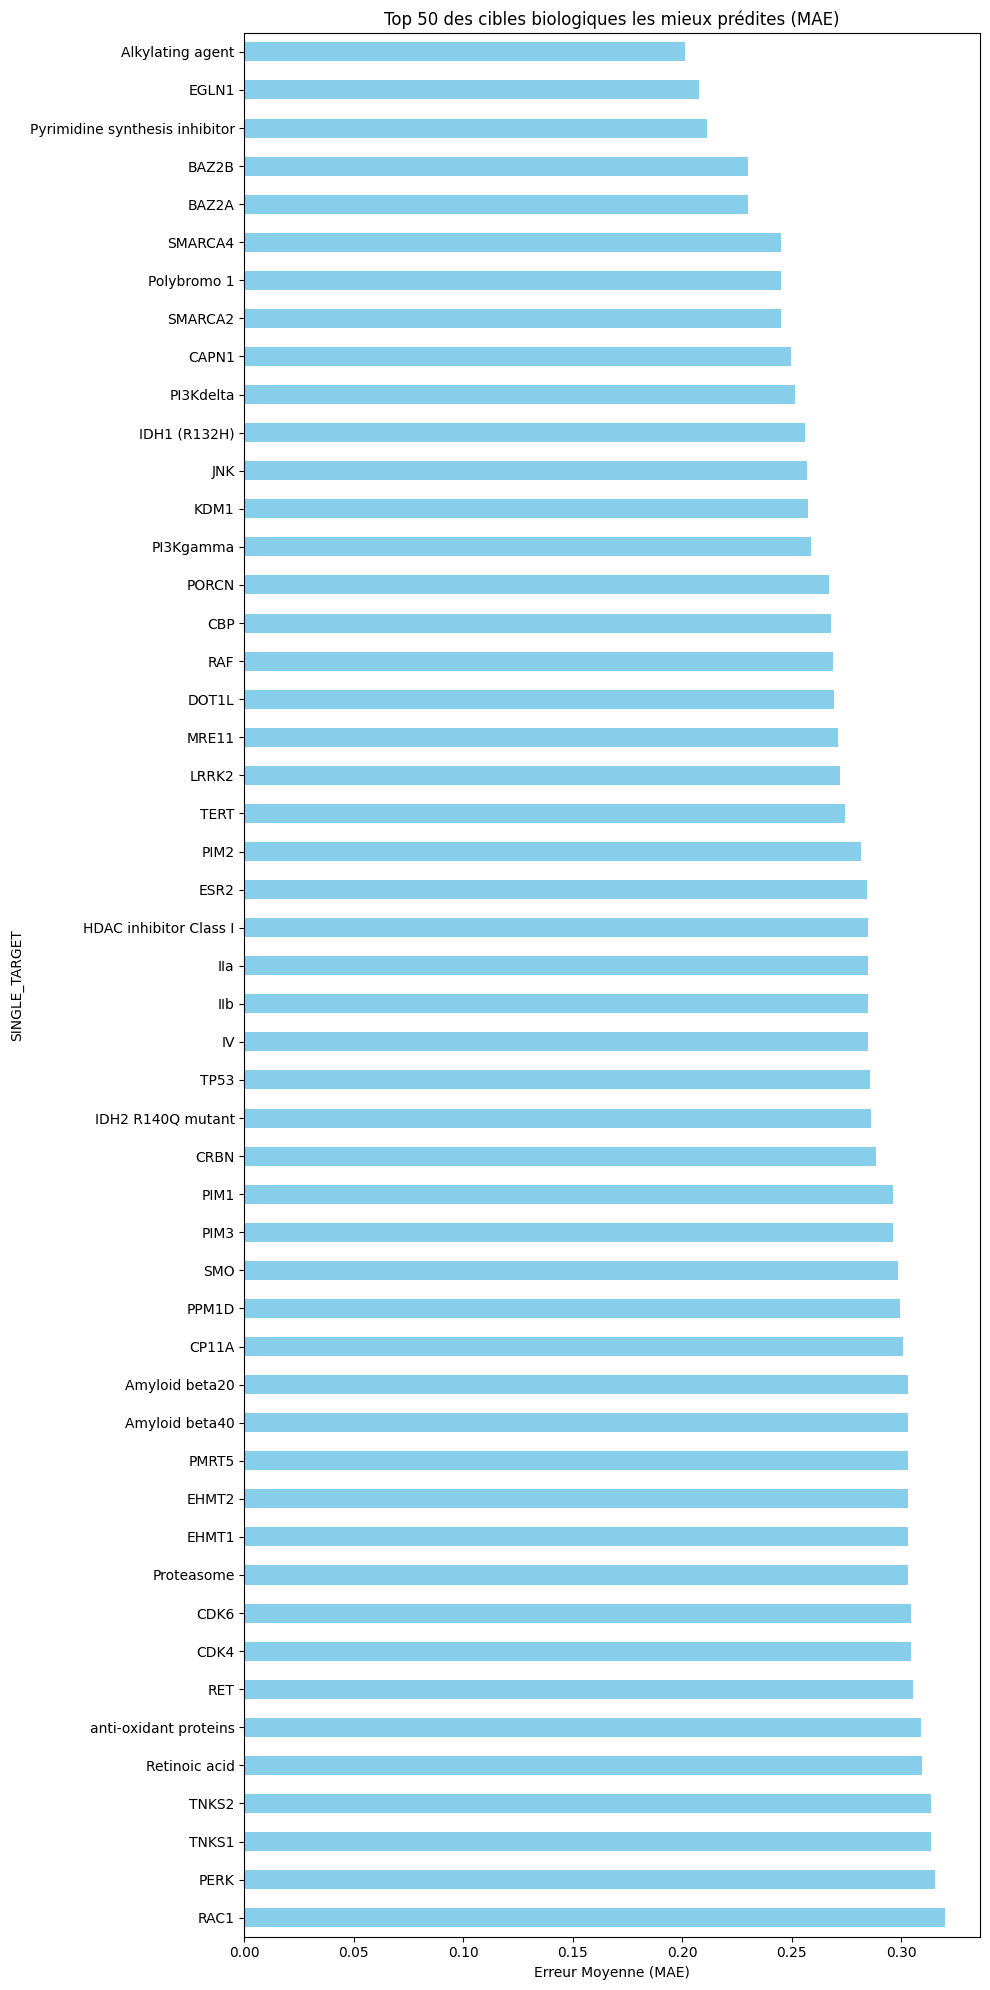

In [137]:
results_df = pd.DataFrame({
    'TARGET': df_meta['TARGET'],
    'Actual': y_test.values.flatten(),
    'Predicted': y_pred
})

results_df = results_df[results_df['TARGET'].str.strip().astype(bool)]

results_df['TARGET_LIST'] = results_df['TARGET'].str.split(', ')

results_df_exploded = results_df.explode('TARGET_LIST')

results_df_exploded = results_df_exploded.rename(columns={'TARGET_LIST': 'SINGLE_TARGET'})

results_df_exploded['Error'] = np.abs(results_df_exploded['Actual'] - results_df_exploded['Predicted'])

results_df_exploded.to_csv("../data/analysis/results_target.csv", index=False)

target_perf = results_df_exploded.groupby('SINGLE_TARGET')['Error'].mean().sort_values()

plt.figure(figsize=(10, 20))
target_perf.head(50).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 50 des cibles biologiques les mieux prédites (MAE)')
plt.xlabel('Erreur Moyenne (MAE)')
plt.tight_layout()
plt.savefig('../plots/Top_cibles.png')
plt.show()

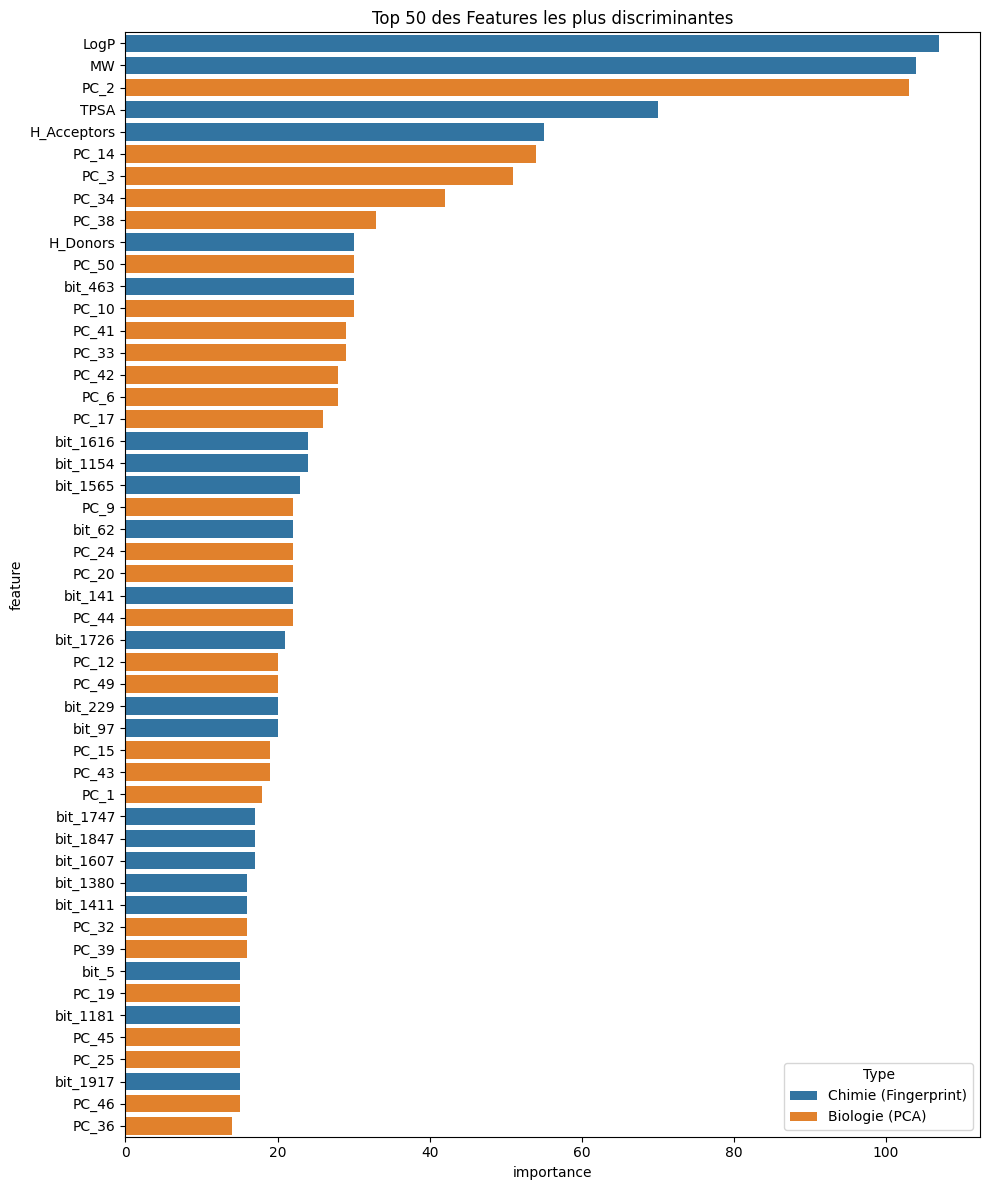

In [138]:
importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# On colore pour distinguer PCA et Bits
importance['Type'] = importance['feature'].apply(lambda x: 'Biologie (PCA)' if 'PC_' in x else 'Chimie (Fingerprint)')

plt.figure(figsize=(10, 12))
sns.barplot(data=importance.head(50), x='importance', y='feature', hue='Type')
plt.title('Top 50 des Features les plus discriminantes')
plt.tight_layout()
plt.savefig('../plots/Top_features.png')
plt.show()

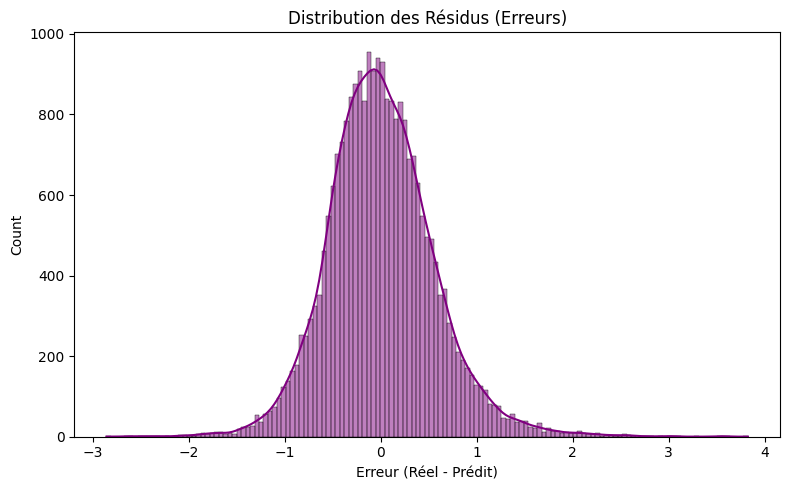

In [139]:
residuals = y_test.values.flatten() - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution des Résidus (Erreurs)')
plt.xlabel('Erreur (Réel - Prédit)')
plt.tight_layout()
plt.savefig('../plots/Distribution_des_Residus.png')
plt.show()

/tmp/ipykernel_11681/1269338839.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genes, x='Weight', y='Gene', palette='coolwarm')


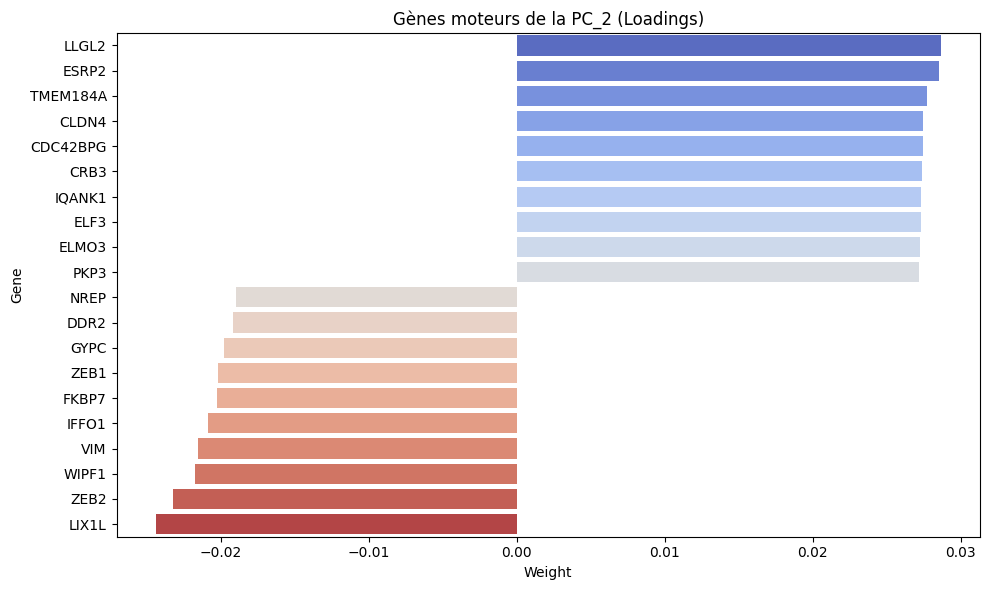

In [140]:
loadings = pca_model.components_[2]

genes_contribution = pd.DataFrame({
    'Gene': cleaned_genes,
    'Weight': loadings
}).sort_values(by='Weight', ascending=False)

top_genes = pd.concat([genes_contribution.head(10), genes_contribution.tail(10)])

top_genes_pc2 = genes_contribution.head(100)['Gene'].tolist()
low_genes_pc2 = genes_contribution.tail(100)['Gene'].tolist()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_genes, x='Weight', y='Gene', palette='coolwarm')
plt.title('Gènes moteurs de la PC_2 (Loadings)')
plt.tight_layout()
plt.savefig('../plots/Genes_PC2.png')
plt.show()

/tmp/ipykernel_11681/3293876395.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genes, x='Weight', y='Gene', palette='coolwarm')


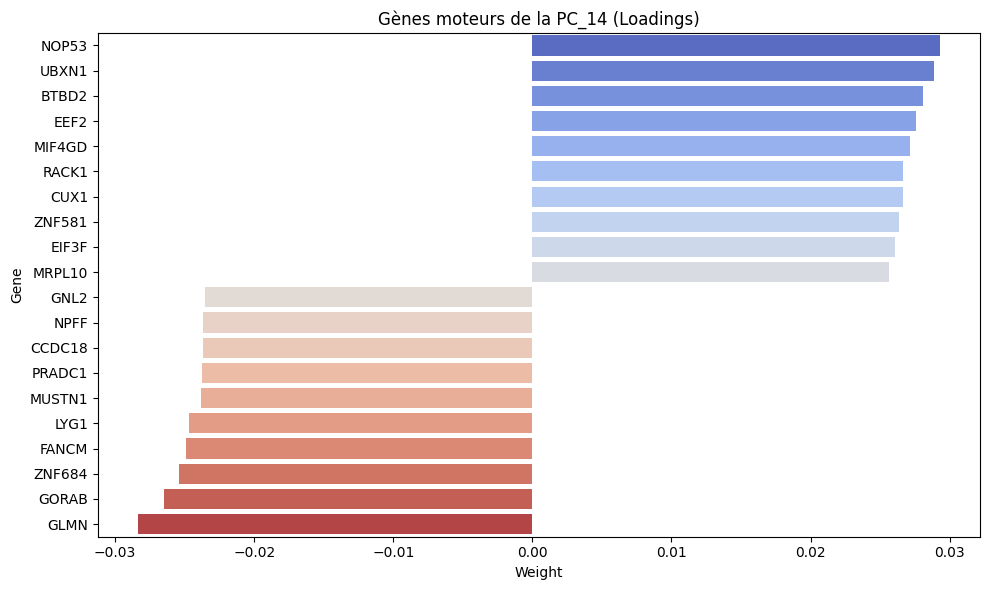

In [141]:
loadings = pca_model.components_[14]

genes_contribution = pd.DataFrame({
    'Gene': cleaned_genes,
    'Weight': loadings
}).sort_values(by='Weight', ascending=False)

top_genes = pd.concat([genes_contribution.head(10), genes_contribution.tail(10)])

top_genes_pc14 = genes_contribution.head(100)['Gene'].tolist()
low_genes_pc14 = genes_contribution.tail(100)['Gene'].tolist()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_genes, x='Weight', y='Gene', palette='coolwarm')
plt.title('Gènes moteurs de la PC_14 (Loadings)')
plt.tight_layout()
plt.savefig('../plots/Genes_PC14.png')
plt.show()

In [126]:
import gseapy as gp

libraries = ['GO_Biological_Process_2023', 'KEGG_2021_Human']

enr_up_pc2 = gp.enrichr(gene_list=top_genes_pc2,
                 gene_sets=libraries,
                 organism='human', 
                 outdir=None)

enr_down_pc2 = gp.enrichr(gene_list=low_genes_pc2,
                 gene_sets=libraries,
                 organism='human', 
                 outdir=None)

# On récupère les résultats
results_up_pc2 = enr_up_pc2.results
results_down_pc2 = enr_down_pc2.results

enr_up_pc14 = gp.enrichr(gene_list=top_genes_pc14,
                 gene_sets=libraries,
                 organism='human', 
                 outdir=None)

enr_down_pc14 = gp.enrichr(gene_list=low_genes_pc14,
                 gene_sets=libraries,
                 organism='human', 
                 outdir=None)

# On récupère les résultats
results_up_pc14 = enr_up_pc14.results
results_down_pc14 = enr_down_pc14.results

EnrichrAPIError: Error sending gene list, status code: 429

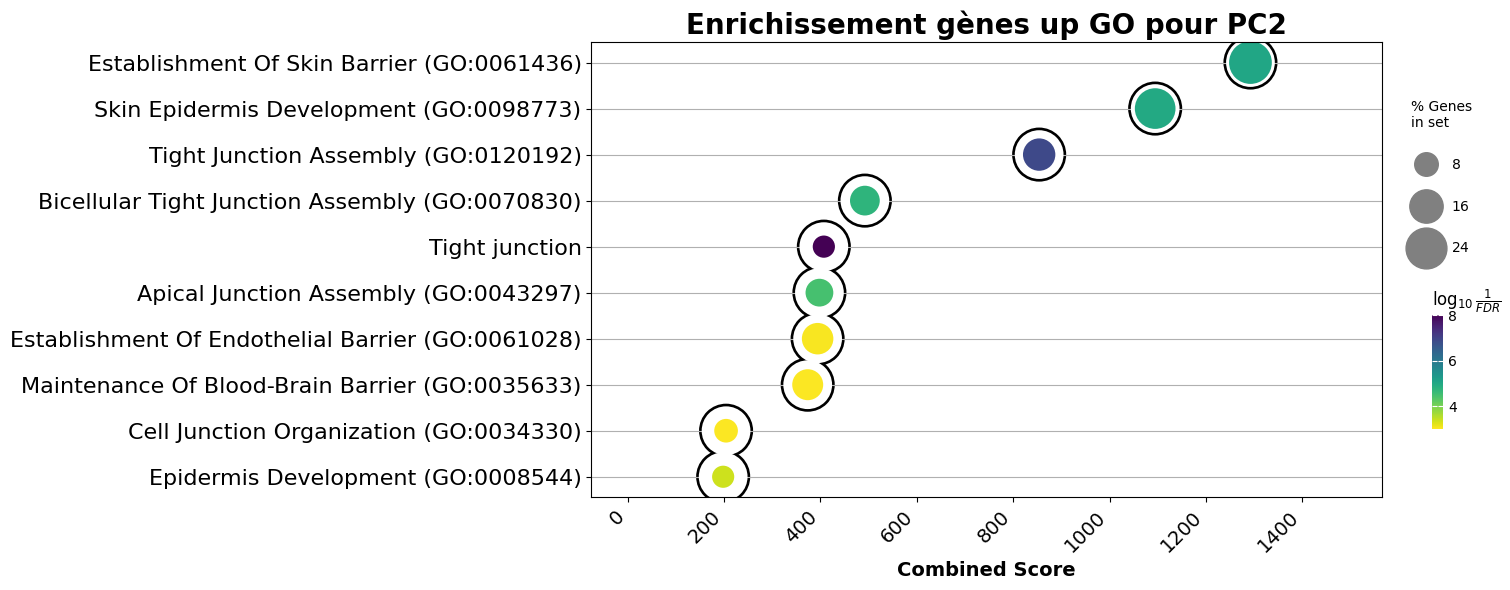

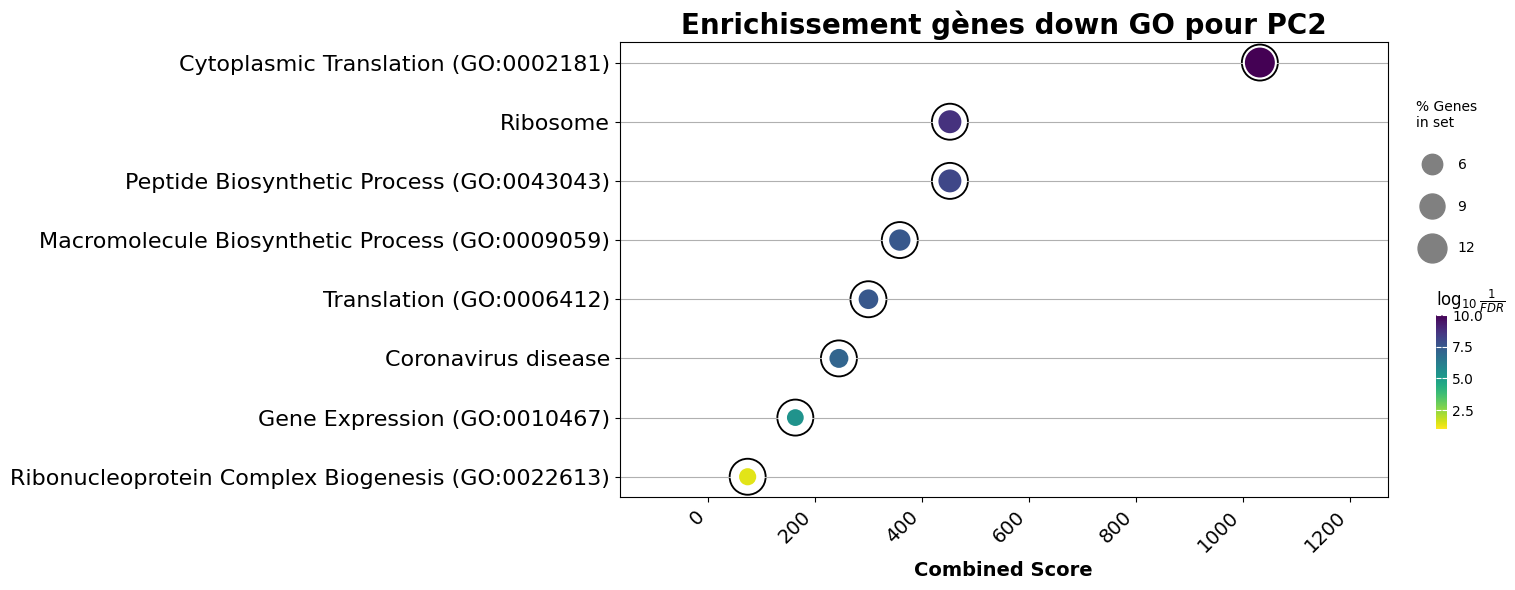

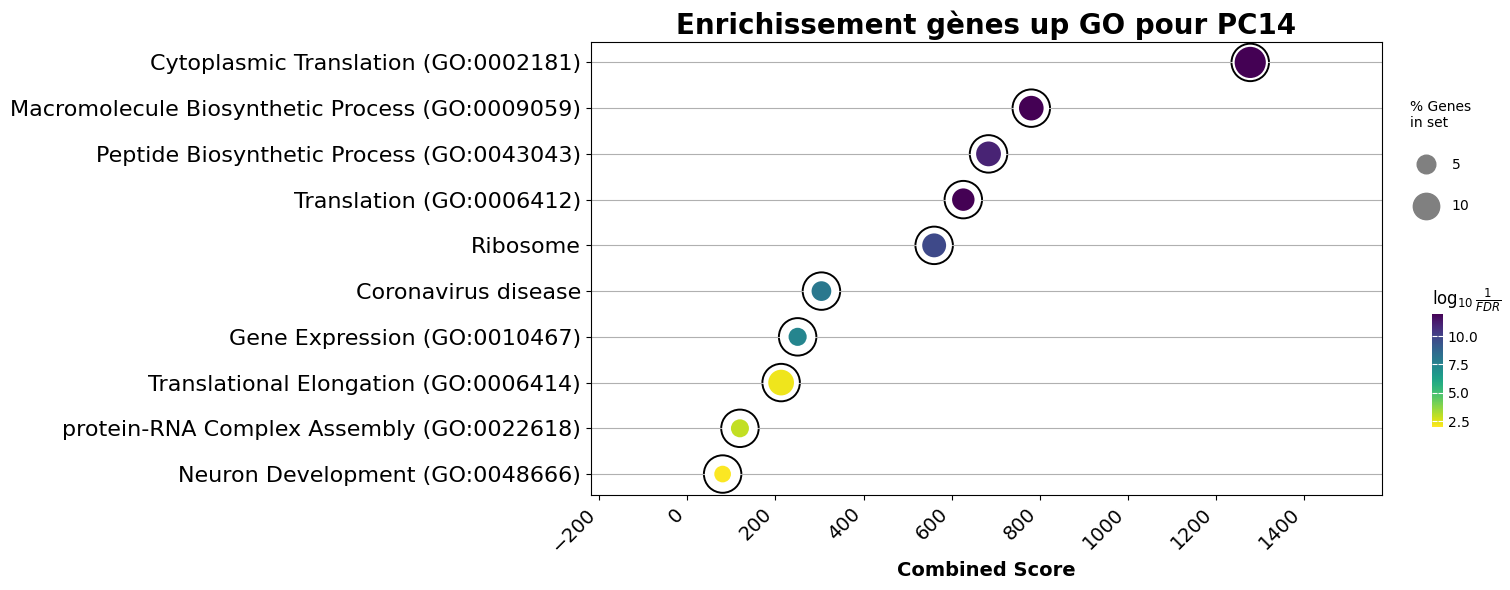

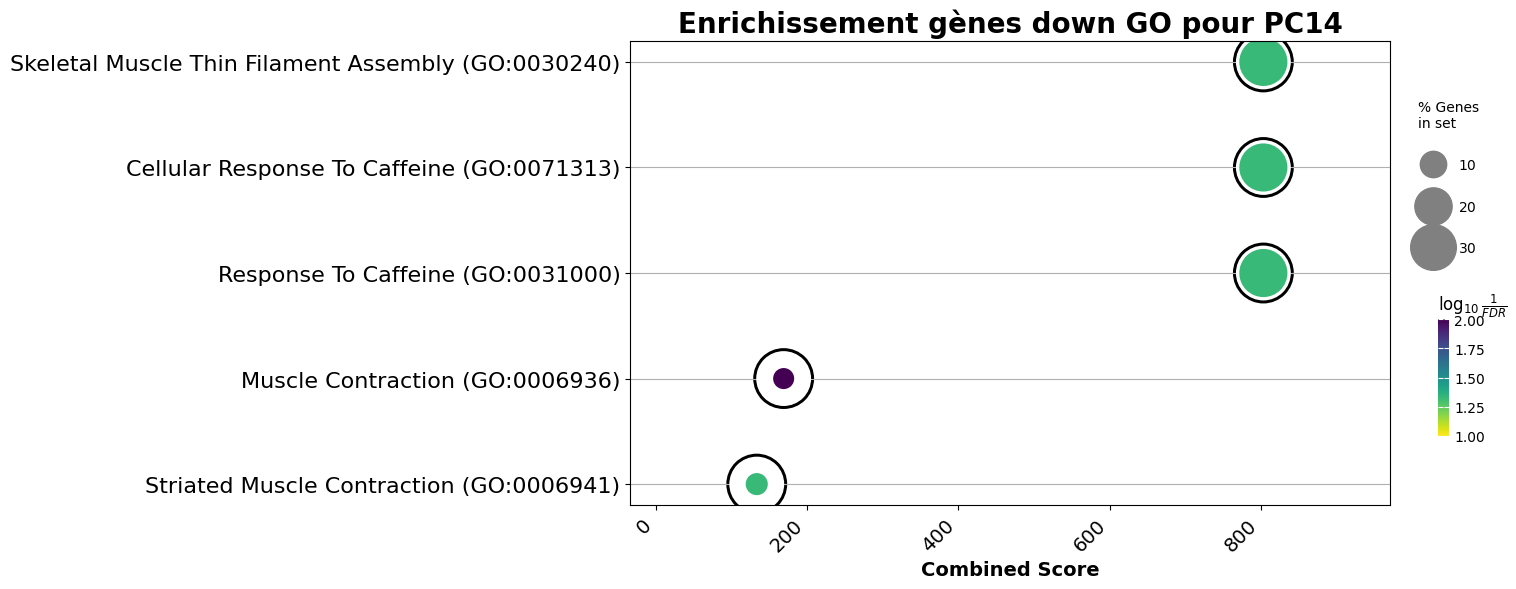

In [149]:
from gseapy import dotplot

# On affiche les 10 termes les plus significatifs
dotplot(results_up_pc2, 
        column="Adjusted P-value", 
        x='Combined Score', # Ou 'Count'
        size=10,
        top_term=10, 
        figsize=(16, 6), 
        title="Enrichissement gènes up GO pour PC2",
        xticklabels_rot=45,
        show_ring=True)
plt.tight_layout()
plt.savefig('../plots/Genes_up_enrich_PC2.png')
plt.show()

dotplot(results_down_pc2, 
        column="Adjusted P-value", 
        x='Combined Score', # Ou 'Count'
        size=10,
        top_term=10, 
        figsize=(16, 6), 
        title="Enrichissement gènes down GO pour PC2",
        xticklabels_rot=45,
        show_ring=True)
plt.tight_layout()
plt.savefig('../plots/Genes_down_enrich_PC2.png')
plt.show()

dotplot(results_up_pc14, 
        column="Adjusted P-value", 
        x='Combined Score', # Ou 'Count'
        size=10,
        top_term=10, 
        figsize=(16, 6), 
        title="Enrichissement gènes up GO pour PC14",
        xticklabels_rot=45,
        show_ring=True)
plt.tight_layout()
plt.savefig('../plots/Genes_up_enrich_PC14.png')
plt.show()

dotplot(results_down_pc14, 
        column="Adjusted P-value", 
        x='Combined Score', # Ou 'Count'
        size=10,
        top_term=10, 
        figsize=(16, 6), 
        title="Enrichissement gènes down GO pour PC14",
        xticklabels_rot=45,
        show_ring=True)
plt.tight_layout()
plt.savefig('../plots/Genes_down_enrich_PC14.png')
plt.show()

In [143]:
results_df_cell = pd.DataFrame({
    'Actual': y_test.values.flatten(),
    'Predicted': y_pred.flatten(),
    'Cancer_Type': df_meta['CANCER_TYPE'],
    'Cell_Line': df_meta['CELL_LINE_NAME']
})

# 2. On calcule l'Erreur Absolue (MAE) pour chaque ligne
results_df_cell['MAE'] = np.abs(results_df_cell['Actual'] - results_df_cell['Predicted'])

In [144]:
cancer_perf = results_df_cell.groupby('Cancer_Type').agg(
    Mean_MAE=('MAE', 'mean'),
    Count=('MAE', 'count') # Important pour la fiabilité statistique
).sort_values('Mean_MAE')

top_cancers = cancer_perf[cancer_perf['Count'] >= 10].head(20)

print("🏆 Les 10 types de cancer les mieux prédits :")
print(top_cancers)

🏆 Les 10 types de cancer les mieux prédits :
                                    Mean_MAE  Count
Cancer_Type                                        
Biliary Tract Carcinoma             0.366005     71
Bladder Carcinoma                   0.368765    587
Burkitt's Lymphoma                  0.371015    322
Prostate Carcinoma                  0.379772    123
Hodgkin's Lymphoma                  0.382988    210
Cervical Carcinoma                  0.392012    259
Esophageal Squamous Cell Carcinoma  0.393104   1100
Glioblastoma                        0.393676    833
Rhabdomyosarcoma                    0.393772    139
Pancreatic Carcinoma                0.393845    593
Osteosarcoma                        0.394582    395
Hepatocellular Carcinoma            0.394976    586
Glioma                              0.395278    170
Other Sarcomas                      0.395990    460
Head and Neck Carcinoma             0.398214    145
Oral Cavity Carcinoma               0.400159    554
Plasma Cell Myeloma

/tmp/ipykernel_11681/1132444206.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Cancer_Type', y='MAE', palette='vlag')


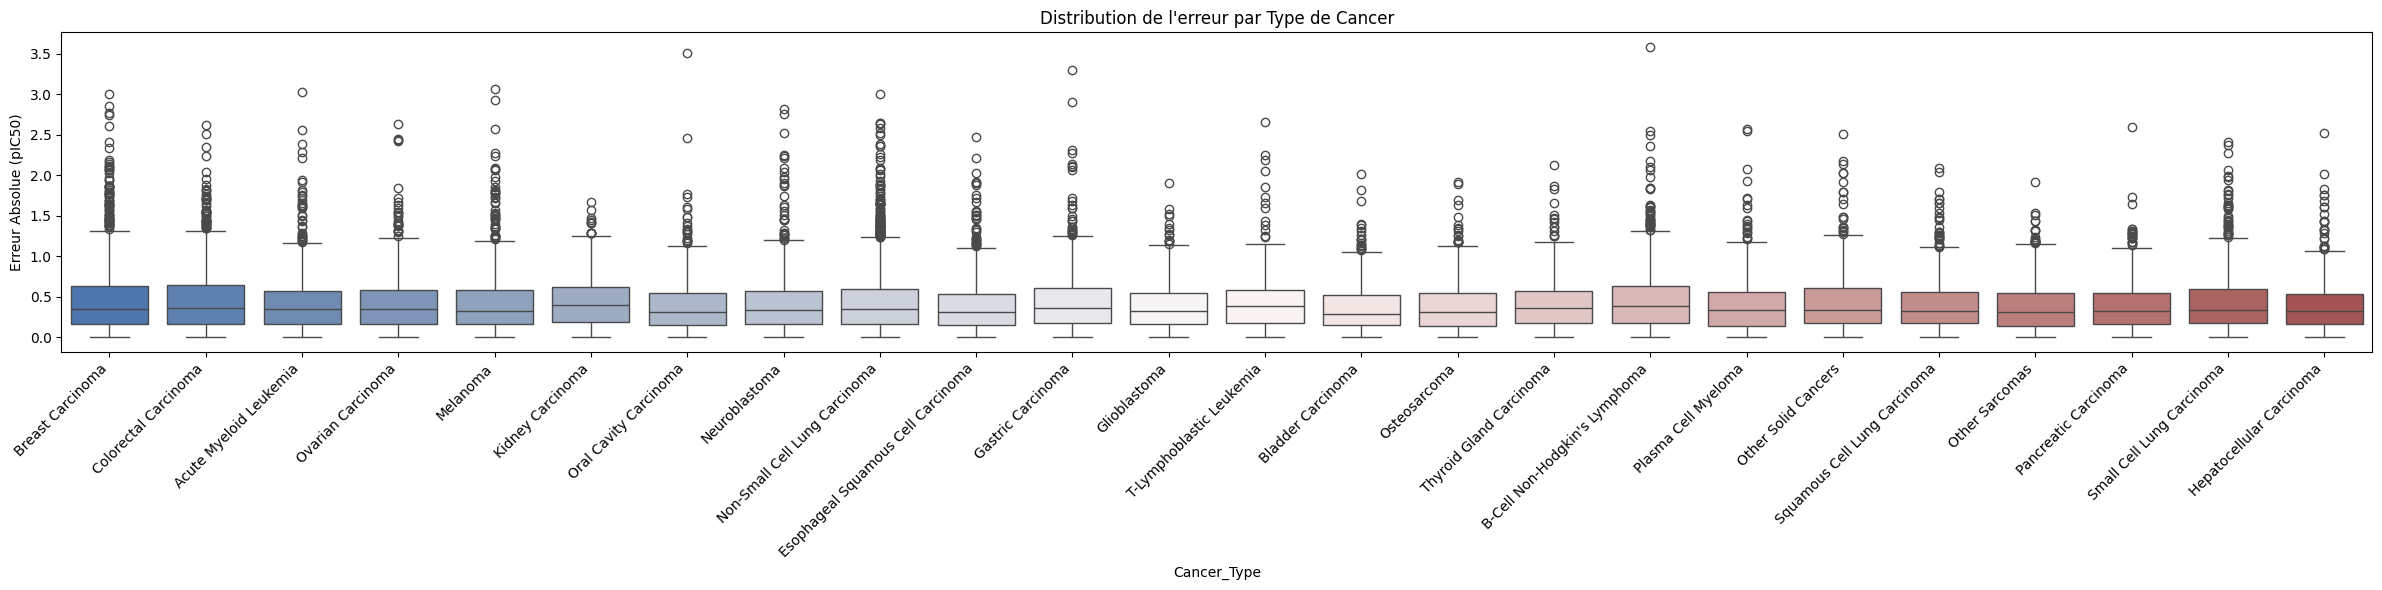

In [145]:
plt.figure(figsize=(24, 6))
# On filtre pour ne garder que les types de cancer les plus fréquents
top_types = results_df_cell['Cancer_Type'].value_counts().head(24).index
df_plot = results_df_cell[results_df_cell['Cancer_Type'].isin(top_types)]

sns.boxplot(data=df_plot, x='Cancer_Type', y='MAE', palette='vlag')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution de l\'erreur par Type de Cancer')
plt.ylabel('Erreur Absolue (pIC50)')
plt.tight_layout()
plt.savefig('../plots/Distribution_de_lerreur_par_Type_de_Cancer.png')
plt.show()

In [146]:
best_cell_line = results_df_cell.groupby('Cell_Line')['MAE'].mean().idxmin()
print(f"La lignée la mieux prédite est : {best_cell_line}")

La lignée la mieux prédite est : LXF-289


/tmp/ipykernel_11681/687500391.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Cell_Line', y='MAE', palette='vlag')


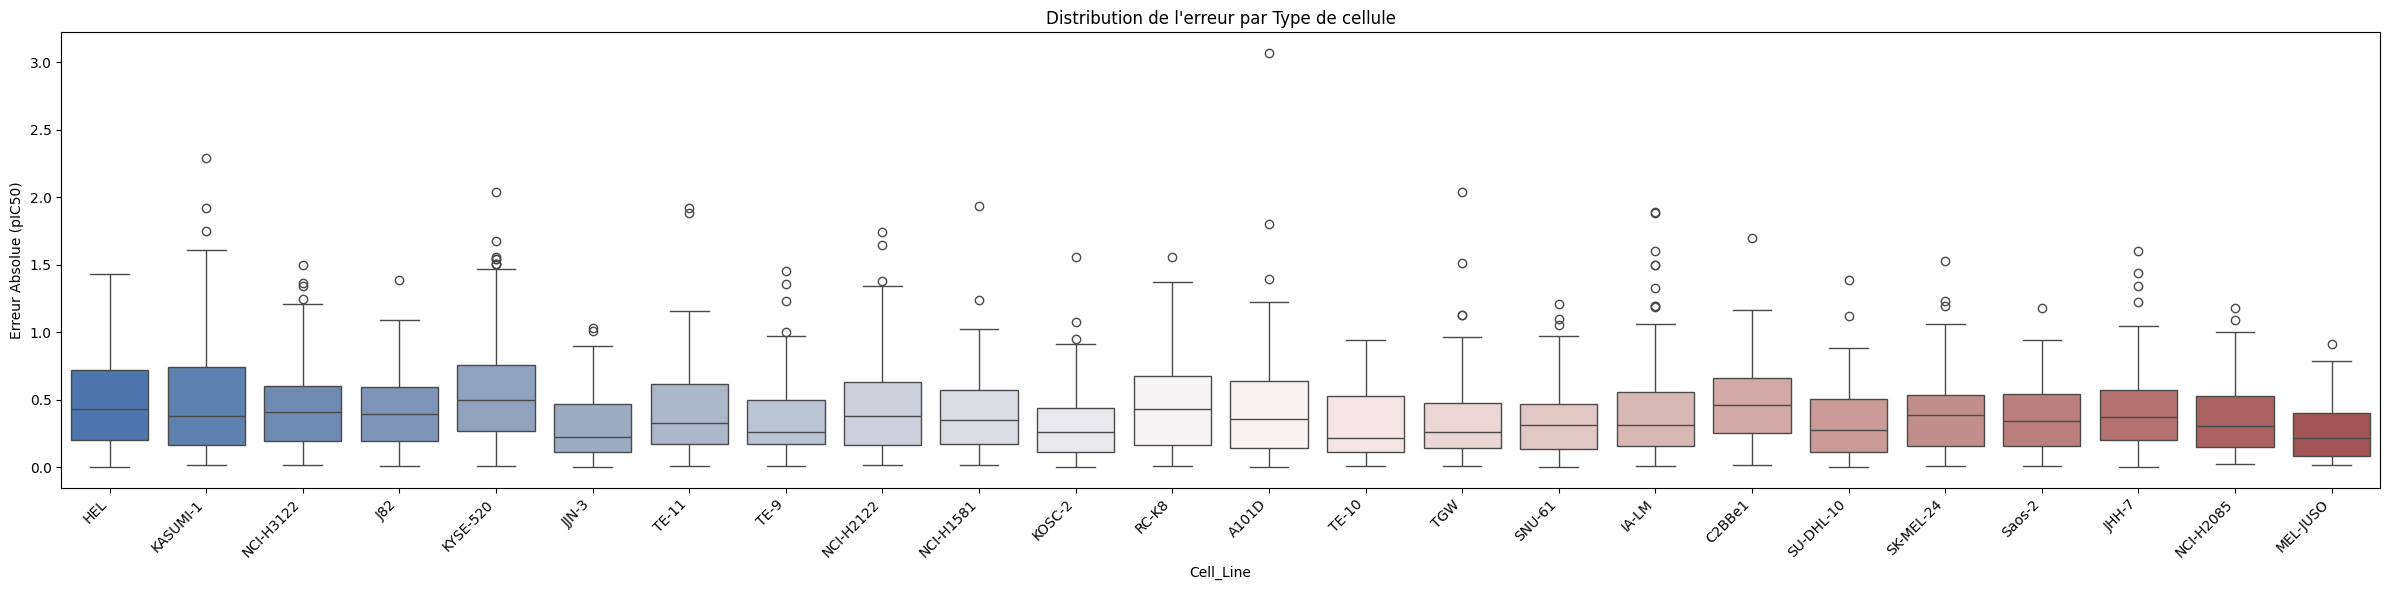

In [147]:
plt.figure(figsize=(24,6))
# On filtre pour ne garder que les types de cancer les plus fréquents
top_types = results_df_cell['Cell_Line'].value_counts().head(24).index
df_plot = results_df_cell[results_df_cell['Cell_Line'].isin(top_types)]

sns.boxplot(data=df_plot, x='Cell_Line', y='MAE', palette='vlag')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution de l\'erreur par Type de cellule')
plt.ylabel('Erreur Absolue (pIC50)')
plt.tight_layout()
plt.savefig('../plots/Distribution_de_lerreur_par_Type_de_cellule.png')
plt.show()